# EfficientRainbow ± FHR on the Atari-100k protocol — full-suite results

**Branch `sac/fhr-sac-implementation-1` · 2026-08-27 · single GB10 · corrected protocol**

Suite-wide companion to `dqn_krull/exp_effrainbow_fhr_krull_results.ipynb`: the same
± FHR comparison on the repo's **EfficientRainbow** recipe — DrQ's "Efficient DQN"
(Kostrikov et al. 2021, Table 4) with the IQN-8 dueling head: NatureCNN encoder,
double DQN, fixed n-step 10 and γ = 0.99, hard target copy every env step,
exponential ε → 0.01 over ~5k steps, replay ratio 2, DrQ shift+intensity
augmentation, Adam (lr 1e-4, eps 1.5e-4) — run over **every game dir with an
`effrainbow100k` manifest**: the official 26-game Atari-100k suite plus Enduro.

**Protocol** (references + reference scores: `src/analysis/atari100k.py`): 100k
agent-env interactions (400k frames, frameskip 4), deterministic ALE (no sticky
actions, minimal action set), sign-clipped rewards for training only, then a separate
final-policy evaluation of **32 episodes at ε = 0.001** reporting **raw game
scores**; HNS = (agent − random)/(human − random). All runs use the **corrected
protocol** (episodic-life training, full-game final evaluation) — the pre-08-21
game-restart runs live in archived `*.v0-gamerestart` manifest families and are never
pooled here. Published numbers are quoted from EfficientZero (Ye et al. 2021, Table
1); random/human are the Wang et al. (2016) 30-no-op references.

**Read before quoting:**
- **Arms**: `baseline` = EfficientRainbow, TD only (`fhr_weight: 0`); `exp3` = the
  same agent + the FHR penalty (**λ = 2, r = 8** — the suite-wide arm; each legend
  restates the recorded overrides). They are each other's controls — the config diff
  is the FHR block alone. Krull's config additionally defines exp7/exp8 (r = 22
  probes); those live in the Krull notebook, not here — this notebook compares the
  arms **common to every game**.
- **Seeds** come from each game config (`experiment.seeds`): seed 0 across the suite,
  0 + 1 on Krull. A single-seed-per-game suite readout is standard at 100k (SimPLe
  reported 1–5), but per-game deltas are noisy — read the suite-level aggregate and
  the win/loss tally, not individual games.
- **Enduro is outside the official suite** (no published 100k baselines): it reports
  against random/human only and never enters aggregates.
- The per-game `include_in_aggregate` config flag (used by the FHR-DQN notebook
  while its sweep was partial) is **not** the aggregate gate here: coverage is
  complete, so the aggregate is simply every game with both arms recorded that is in
  the official suite — the figure titles state the exact count.

## 0 · Launch — games × arms × seeds, parallel subprocesses

Everything below analyses the runs recorded in each game dir's
`cached/effrainbow100k_runs_manifest.json`; completed runs are skipped on relaunch,
so the launch cell is idempotent. A 100k EfficientRainbow run is hours on the GB10 —
launch and come back.

In [1]:
import pathlib, sys
EXPS = pathlib.Path.cwd().parent / "src"           # experiments/src
if str(EXPS) not in sys.path:
    sys.path.insert(0, str(EXPS))
import run_fhrdqn_atari100k as launcher
launcher.CONFIG = "config_effrainbow_100k.yaml"    # this notebook's recipe/family

LAUNCH = False       # True: train whatever is missing from the manifests
FORCE_EXP = False    # True: retrain exp arms with the current config (never baselines)
if LAUNCH:
    manifests = launcher.launch_all(games=None, experiments=None,
                                    max_workers=3, force=FORCE_EXP)
    print({g: sorted(m["runs"]) for g, m in manifests.items()})
else:
    print("LAUNCH = False — analysing existing runs only")

LAUNCH = False — analysing existing runs only


In [2]:
import json, warnings
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="All-NaN slice encountered")
import numpy as np
import matplotlib.pyplot as plt
import yaml

SRC = pathlib.Path.cwd().parents[1] / "src"        # repo library code
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from analysis.atari100k import REFERENCE, BASELINES, BENCHMARK_GAMES, \
    ATARI100K_ENV_STEPS, hns

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False,
})

# Every game dir that carries this recipe's config + a non-empty manifest.
GAMES = [g for g in sorted(launcher.GAME_DIRS)
         if (launcher._game_dir(g) / launcher.CONFIG).exists()
         and launcher._load_manifest(launcher._game_dir(g))["runs"]]
GAME_KEYS = {g: launcher.config_game_key(g) for g in GAMES}

# The cross-game comparison covers the arms common to every game.
ARMS = ["baseline", "exp3"]

RESULTS = {}      # game -> arm -> {"runs", "means" (per-seed eval means), "mean"}
for g in GAMES:
    RESULTS[g] = {}
    for arm in ARMS:
        if arm not in launcher.arms_of(g):
            continue
        runs = launcher.load_runs(g, arm)
        means = np.array([r["eval_summary"]["mean"] for r in runs])
        RESULTS[g][arm] = {"runs": runs, "means": means, "mean": float(means.mean())}

# Arm labels/colours from the RECORDED overrides (warn when a config drifted).
def _norm(d):
    return {k: (float(v) if isinstance(v, (int, float)) and not isinstance(v, bool)
                else v) for k, v in (d or {}).items()}
ov_seen = {}
for g in GAMES:
    man = launcher._load_manifest(launcher._game_dir(g))
    got = man.get("overrides", {}).get("exp3")
    cfg = yaml.safe_load(open(launcher._game_dir(g) / launcher.CONFIG))
    want = (cfg["experiment"].get("fhr_experiments") or {}).get(3) or \
           (cfg["experiment"].get("fhr_experiments") or {}).get("3")
    if got is not None and want is not None and _norm(got) != _norm(want):
        print(f"WARNING {g}: recorded exp3 {got} != config {want} — "
              f"FORCE_EXP retrains")
    ov_seen[g] = got or want or {}
ov = next(iter(ov_seen.values()))
assert all(_norm(o) == _norm(ov) for o in ov_seen.values()), \
    f"exp3 overrides differ across games: { {g: o for g, o in ov_seen.items()} }"

OUR_LABEL = {"baseline": "EfficientRainbow (TD only)",
             "exp3": f"+ FHR (λ={ov.get('fhr_weight', '?'):g}, "
                     f"r={ov.get('fhr_order', '?')})"}
OUR_COLOR = {"baseline": "steelblue", "exp3": "indianred"}
PUBLISHED = ["SimPLe", "OTRainbow", "CURL", "DrQ", "SPR", "MuZero", "EfficientZero"]

# Aggregate = official-suite games with both arms recorded (Enduro never enters).
AGG_GAMES = [g for g in GAMES if GAME_KEYS[g] in BENCHMARK_GAMES
             and all(a in RESULTS[g] for a in ARMS)]
print(f"analysing {len(GAMES)} game(s); aggregate covers {len(AGG_GAMES)} of "
      f"{len(BENCHMARK_GAMES)} suite games")
print("exp3 overrides:", ov)

analysing 27 game(s); aggregate covers 26 of 26 suite games
exp3 overrides: {'fhr_weight': 2, 'fhr_order': 8}


## 1 · Results table — EfficientZero-style

Raw final-evaluation game scores (mean over seeds of the 32-episode mean). Published
columns contextualise the axis; they are their own (heavier) recipes, not ablations
of ours. Δ and the tally line are the suite-level readout that matters at one seed
per game.

In [3]:
hdr = ["Game", "Random", "Human", *PUBLISHED,
       "EffRainbow", "+FHR", "Δ", "ΔHNS"]
rows, wins, losses, ties, dhns_all = [], [], [], [], []
for g in GAMES:
    k = GAME_KEYS[g]
    row = [k, f"{REFERENCE[k]['random']:.1f}", f"{REFERENCE[k]['human']:.1f}"]
    row += [f"{BASELINES[k][m]:.1f}" if m in BASELINES[k] else "—"
            for m in PUBLISHED]
    b = RESULTS[g].get("baseline"); f = RESULTS[g].get("exp3")
    row += [f"{b['mean']:.1f}" if b else "—", f"{f['mean']:.1f}" if f else "—"]
    if b and f:
        d = f["mean"] - b["mean"]
        dh = hns(f["mean"], k) - hns(b["mean"], k)
        row += [f"{d:+.1f}", f"{dh:+.3f}"]
        dhns_all.append((k, dh))
        (wins if d > 0 else losses if d < 0 else ties).append(k)
    else:
        row += ["—", "—"]
    rows.append(row)
w = [max(len(r[i]) for r in [hdr] + rows) for i in range(len(hdr))]
for r in [hdr] + rows:
    print("  ".join(s.rjust(w[i]) for i, s in enumerate(r)))
print(f"\nFHR vs baseline, raw score: {len(wins)} wins / {len(losses)} losses"
      f" / {len(ties)} ties on {len(dhns_all)} games")
dh = np.array([d for _, d in dhns_all])
print(f"per-game ΔHNS: mean {dh.mean():+.3f}  median {np.median(dh):+.3f}  "
      f"IQR [{np.percentile(dh, 25):+.3f}, {np.percentile(dh, 75):+.3f}]")
print("biggest wins  :", sorted(dhns_all, key=lambda t: -t[1])[:5])
print("biggest losses:", sorted(dhns_all, key=lambda t: t[1])[:5])

          Game   Random    Human   SimPLe  OTRainbow     CURL      DrQ      SPR   MuZero  EfficientZero  EffRainbow     +FHR        Δ    ΔHNS
         Alien    227.8   7127.7    616.9      824.7    558.2    771.2    801.5    530.0          808.5       631.6   1201.2   +569.7  +0.083
        Amidar      5.8   1719.5     88.0       82.8    142.1    102.8    176.3     38.8          148.6       109.9    119.8     +9.9  +0.006
       Assault    222.4    742.0    527.2      351.9    600.6    452.4    571.0    500.1         1263.1       598.7    593.5     -5.2  -0.010
       Asterix    210.0   8503.3   1128.3      628.5    734.5    603.5    977.8   1734.0        25557.8       948.4    715.6   -232.8  -0.028
     BankHeist     14.2    753.1     34.2      182.1    131.6    168.9    380.9    192.5          351.0        52.5    513.4   +460.9  +0.624
    BattleZone   2360.0  37187.5   5184.4     4060.6  14870.0  12954.0  16651.0   7687.5        13871.2      9937.5  10218.8   +281.2  +0.008
      

## 2 · Human-normalised score per game

Grey bars = published methods; coloured = our two arms (dots = individual seeds).
Figures also land in each run dir's `figures/` so the result viewer shows them
next to the run.

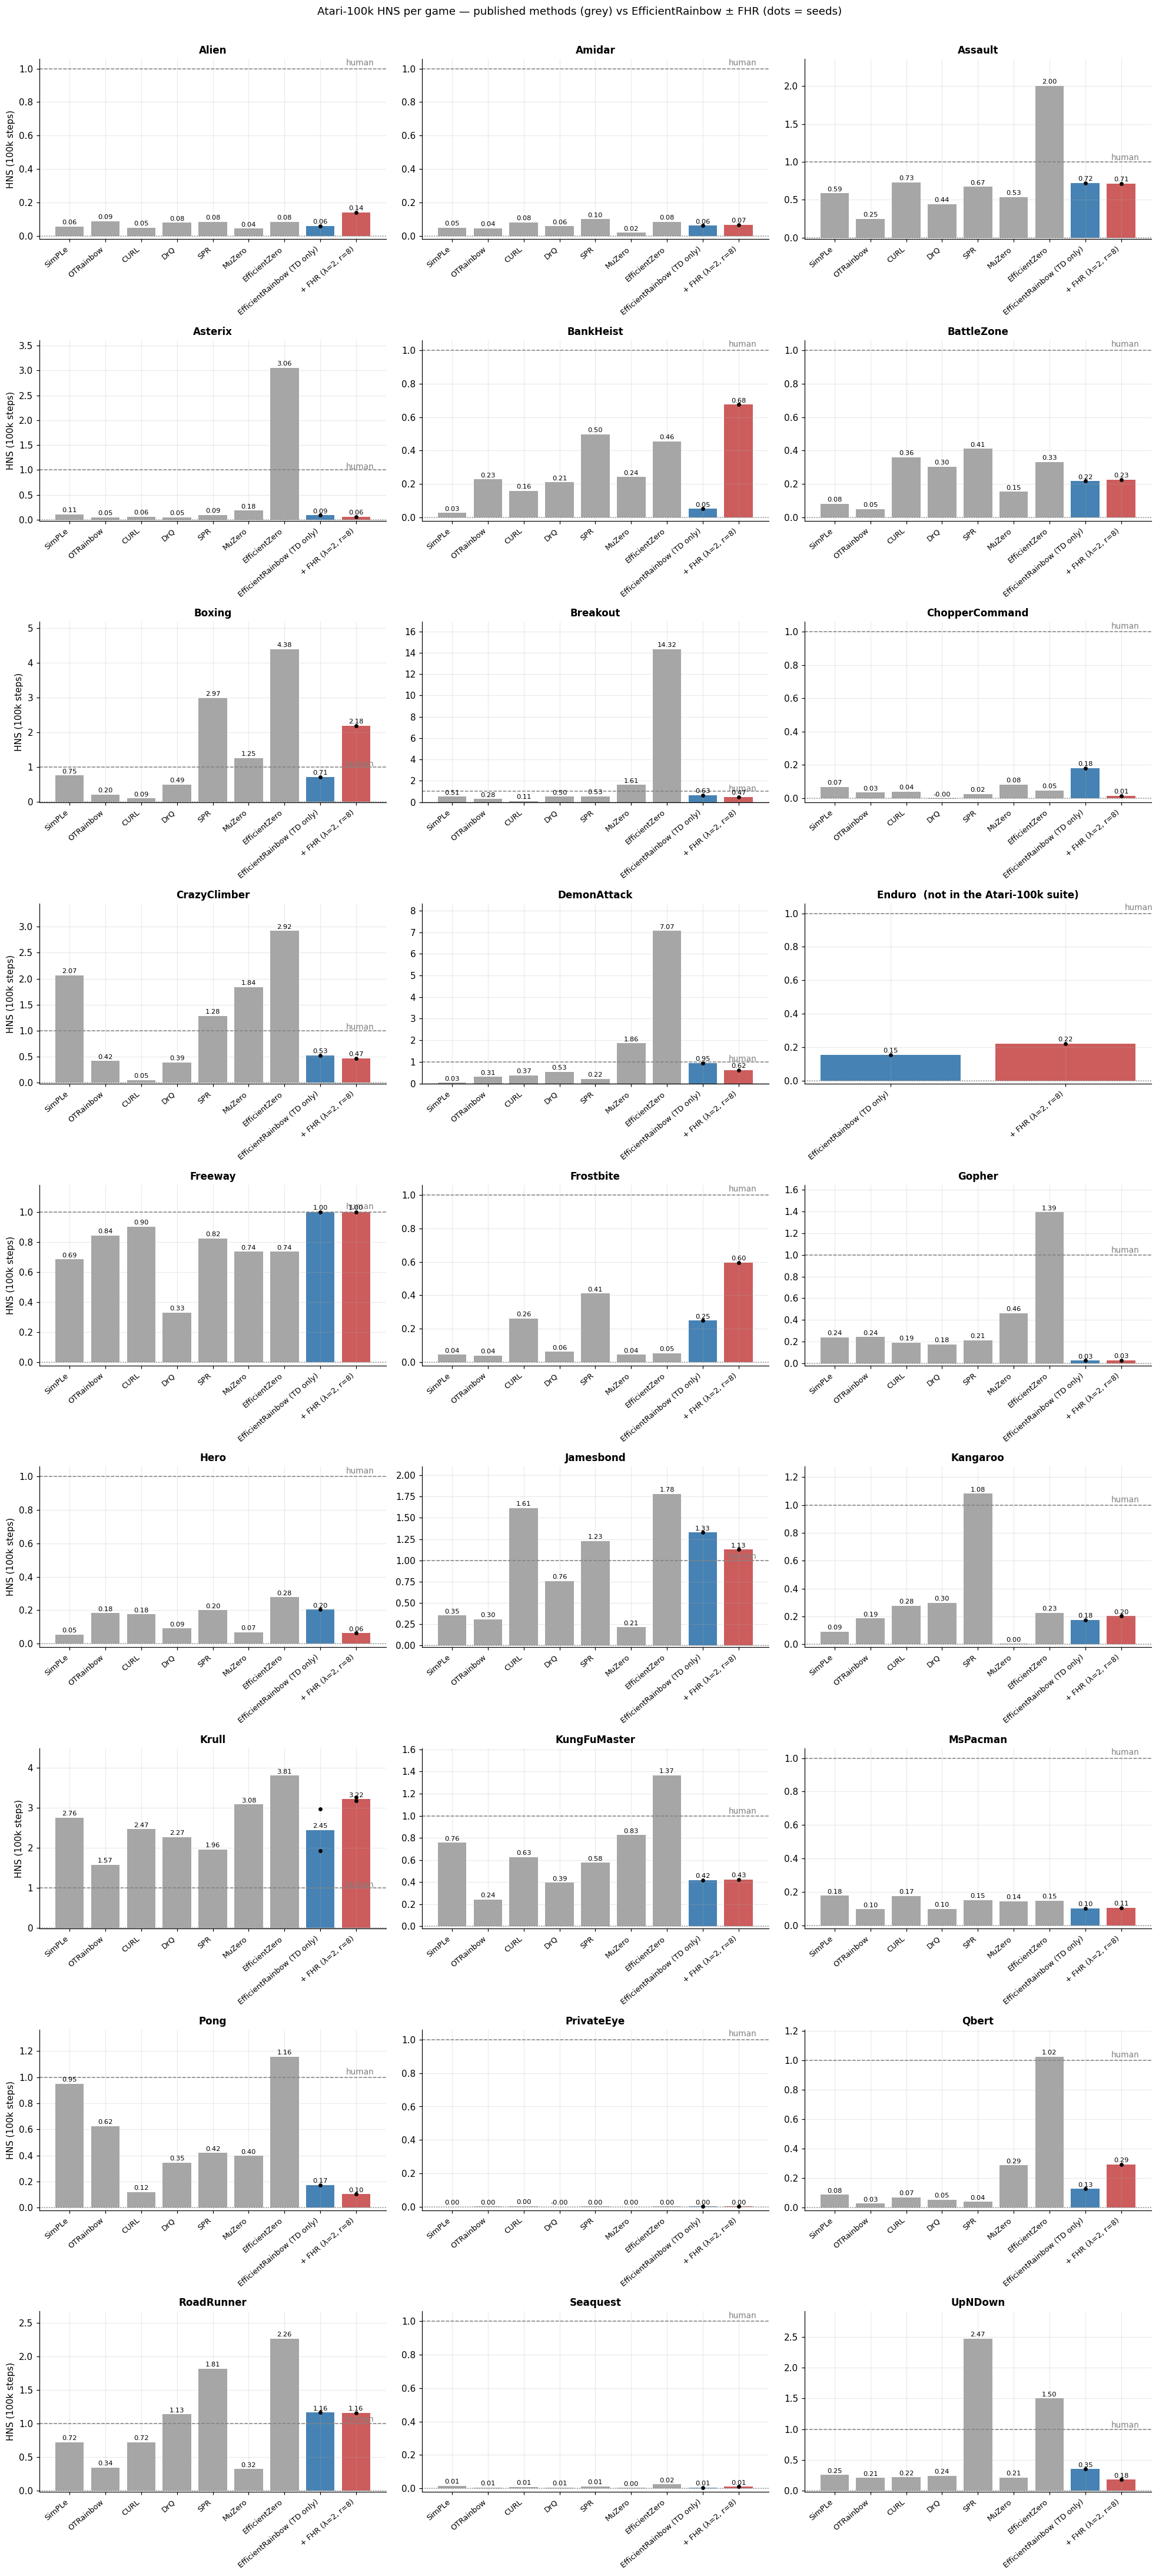

In [4]:
FIGDIR = pathlib.Path.cwd() / "cached" / "atari100k_effrainbow_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

def save_and_show(fig, slug):
    fig.savefig(FIGDIR / f"{slug}.png", dpi=200, bbox_inches="tight")
    for g in GAMES:
        for arm in RESULTS[g]:
            for r in RESULTS[g][arm]["runs"]:
                d = pathlib.Path(r["run_dir"]) / "figures"
                d.mkdir(exist_ok=True)
                fig.savefig(d / f"comparison_{slug}.png", dpi=150,
                            bbox_inches="tight")
    plt.show()

NCOLS = 3
NROWS = -(-len(GAMES) // NCOLS)
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(6 * NCOLS, 4.4 * NROWS),
                         squeeze=False)
for ax in axes.flat[len(GAMES):]:
    ax.set_visible(False)
for ax, g in zip(axes.flat, GAMES):
    k = GAME_KEYS[g]
    names, vals, cols = [], [], []
    for m in PUBLISHED:
        if m in BASELINES[k]:
            names.append(m); vals.append(hns(BASELINES[k][m], k)); cols.append("0.65")
    for a in ARMS:
        if a in RESULTS[g]:
            names.append(OUR_LABEL[a]); vals.append(hns(RESULTS[g][a]["mean"], k))
            cols.append(OUR_COLOR[a])
    x = np.arange(len(names))
    ax.bar(x, vals, color=cols)
    for a in ARMS:
        if a in RESULTS[g]:
            i = names.index(OUR_LABEL[a])
            seed_h = [hns(v, k) for v in RESULTS[g][a]["means"]]
            ax.scatter([i] * len(seed_h), seed_h, color="k", s=12, zorder=3)
    ax.axhline(1.0, ls="--", c="gray", lw=1)
    ax.axhline(0.0, ls=":", c="gray", lw=1)
    top = max([1.06] + [v * 1.18 for v in vals])
    ax.text(len(names) - 0.5, 1.02, "human", ha="right", fontsize=9, color="gray")
    for xi, v in zip(x, vals):
        ax.text(xi, v + top * 0.012, f"{v:.2f}", ha="center", fontsize=7.5)
    ax.set_ylim(min(0, min(vals) * 1.2 if vals else 0) - 0.02, top)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=40, ha="right", fontsize=8.5)
    ax.set_title(k + ("" if BASELINES[k] else "  (not in the Atari-100k suite)"))
for row in axes:
    row[0].set_ylabel("HNS (100k steps)")
fig.suptitle("Atari-100k HNS per game — published methods (grey) vs "
             "EfficientRainbow ± FHR (dots = seeds)", y=1.0 + 0.03 / NROWS)
fig.tight_layout()
save_and_show(fig, "atari100k_effrainbow_hns_per_game")

## 3 · Aggregate over the suite games

Mean and median HNS over the covered official-suite games (Enduro excluded by
construction). The title states the coverage; at 26/26 this is the full benchmark
aggregate.

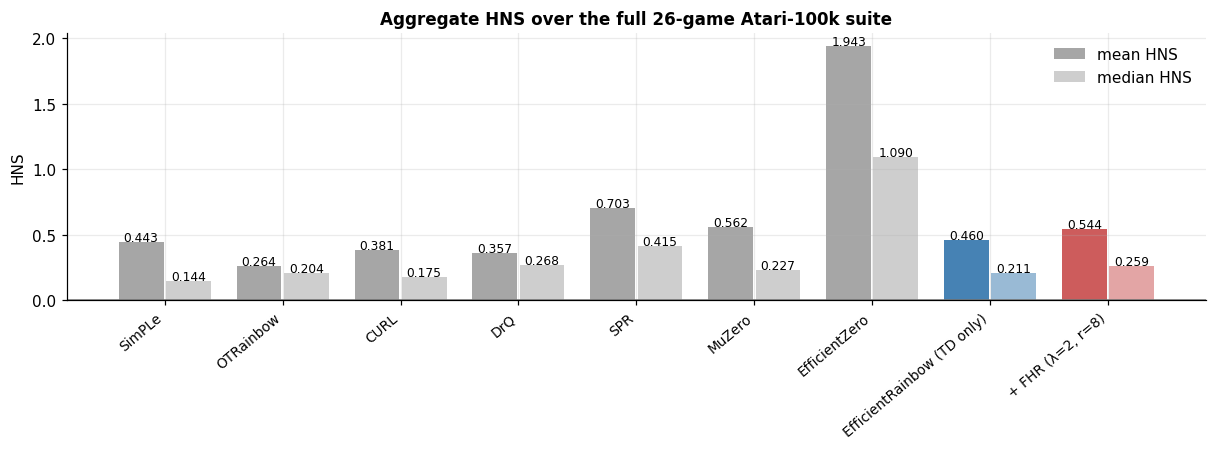

SimPLe                       mean  0.443   median  0.144
OTRainbow                    mean  0.264   median  0.204
CURL                         mean  0.381   median  0.175
DrQ                          mean  0.357   median  0.268
SPR                          mean  0.703   median  0.415
MuZero                       mean  0.562   median  0.227
EfficientZero                mean  1.943   median  1.090
EfficientRainbow (TD only)   mean  0.460   median  0.211
+ FHR (λ=2, r=8)             mean  0.544   median  0.259


In [5]:
assert AGG_GAMES
AGG_KEYS = [GAME_KEYS[g] for g in AGG_GAMES]

methods, cols, agg_mean, agg_med = [], [], [], []
for m in PUBLISHED:
    per = [hns(BASELINES[k][m], k) for k in AGG_KEYS]
    methods.append(m); cols.append("0.65")
    agg_mean.append(float(np.mean(per))); agg_med.append(float(np.median(per)))
for a in ARMS:
    per = [hns(RESULTS[g][a]["mean"], GAME_KEYS[g]) for g in AGG_GAMES]
    methods.append(OUR_LABEL[a]); cols.append(OUR_COLOR[a])
    agg_mean.append(float(np.mean(per))); agg_med.append(float(np.median(per)))

x = np.arange(len(methods))
fig, ax = plt.subplots(figsize=(max(10, 1.25 * len(methods)), 4.2))
b1 = ax.bar(x - 0.2, agg_mean, width=0.38, color=cols, label="mean HNS")
b2 = ax.bar(x + 0.2, agg_med, width=0.38, color=cols, alpha=0.55,
            label="median HNS")
for bs in (b1, b2):
    for b in bs:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.008,
                f"{b.get_height():.3f}", ha="center", fontsize=8)
ax.axhline(0, c="gray", lw=1)
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("HNS")
scope = ("the full 26-game Atari-100k suite"
         if len(AGG_KEYS) == len(BENCHMARK_GAMES)
         else f"{len(AGG_KEYS)} covered suite games (subset — indicative only)")
ax.set_title(f"Aggregate HNS over {scope}")
ax.legend()
fig.tight_layout()
save_and_show(fig, "atari100k_effrainbow_hns_aggregate")
for m, mn, md_ in zip(methods, agg_mean, agg_med):
    print(f"{m:28s} mean {mn:6.3f}   median {md_:6.3f}")

## 4 · Learning curves — raw training return vs environment steps

Training-time full-game returns (life segments stitched by the logger's steps
column), rolling-20, one panel per game. Single-seed games show the curve without a
band; Krull shows the two-seed min–max band.

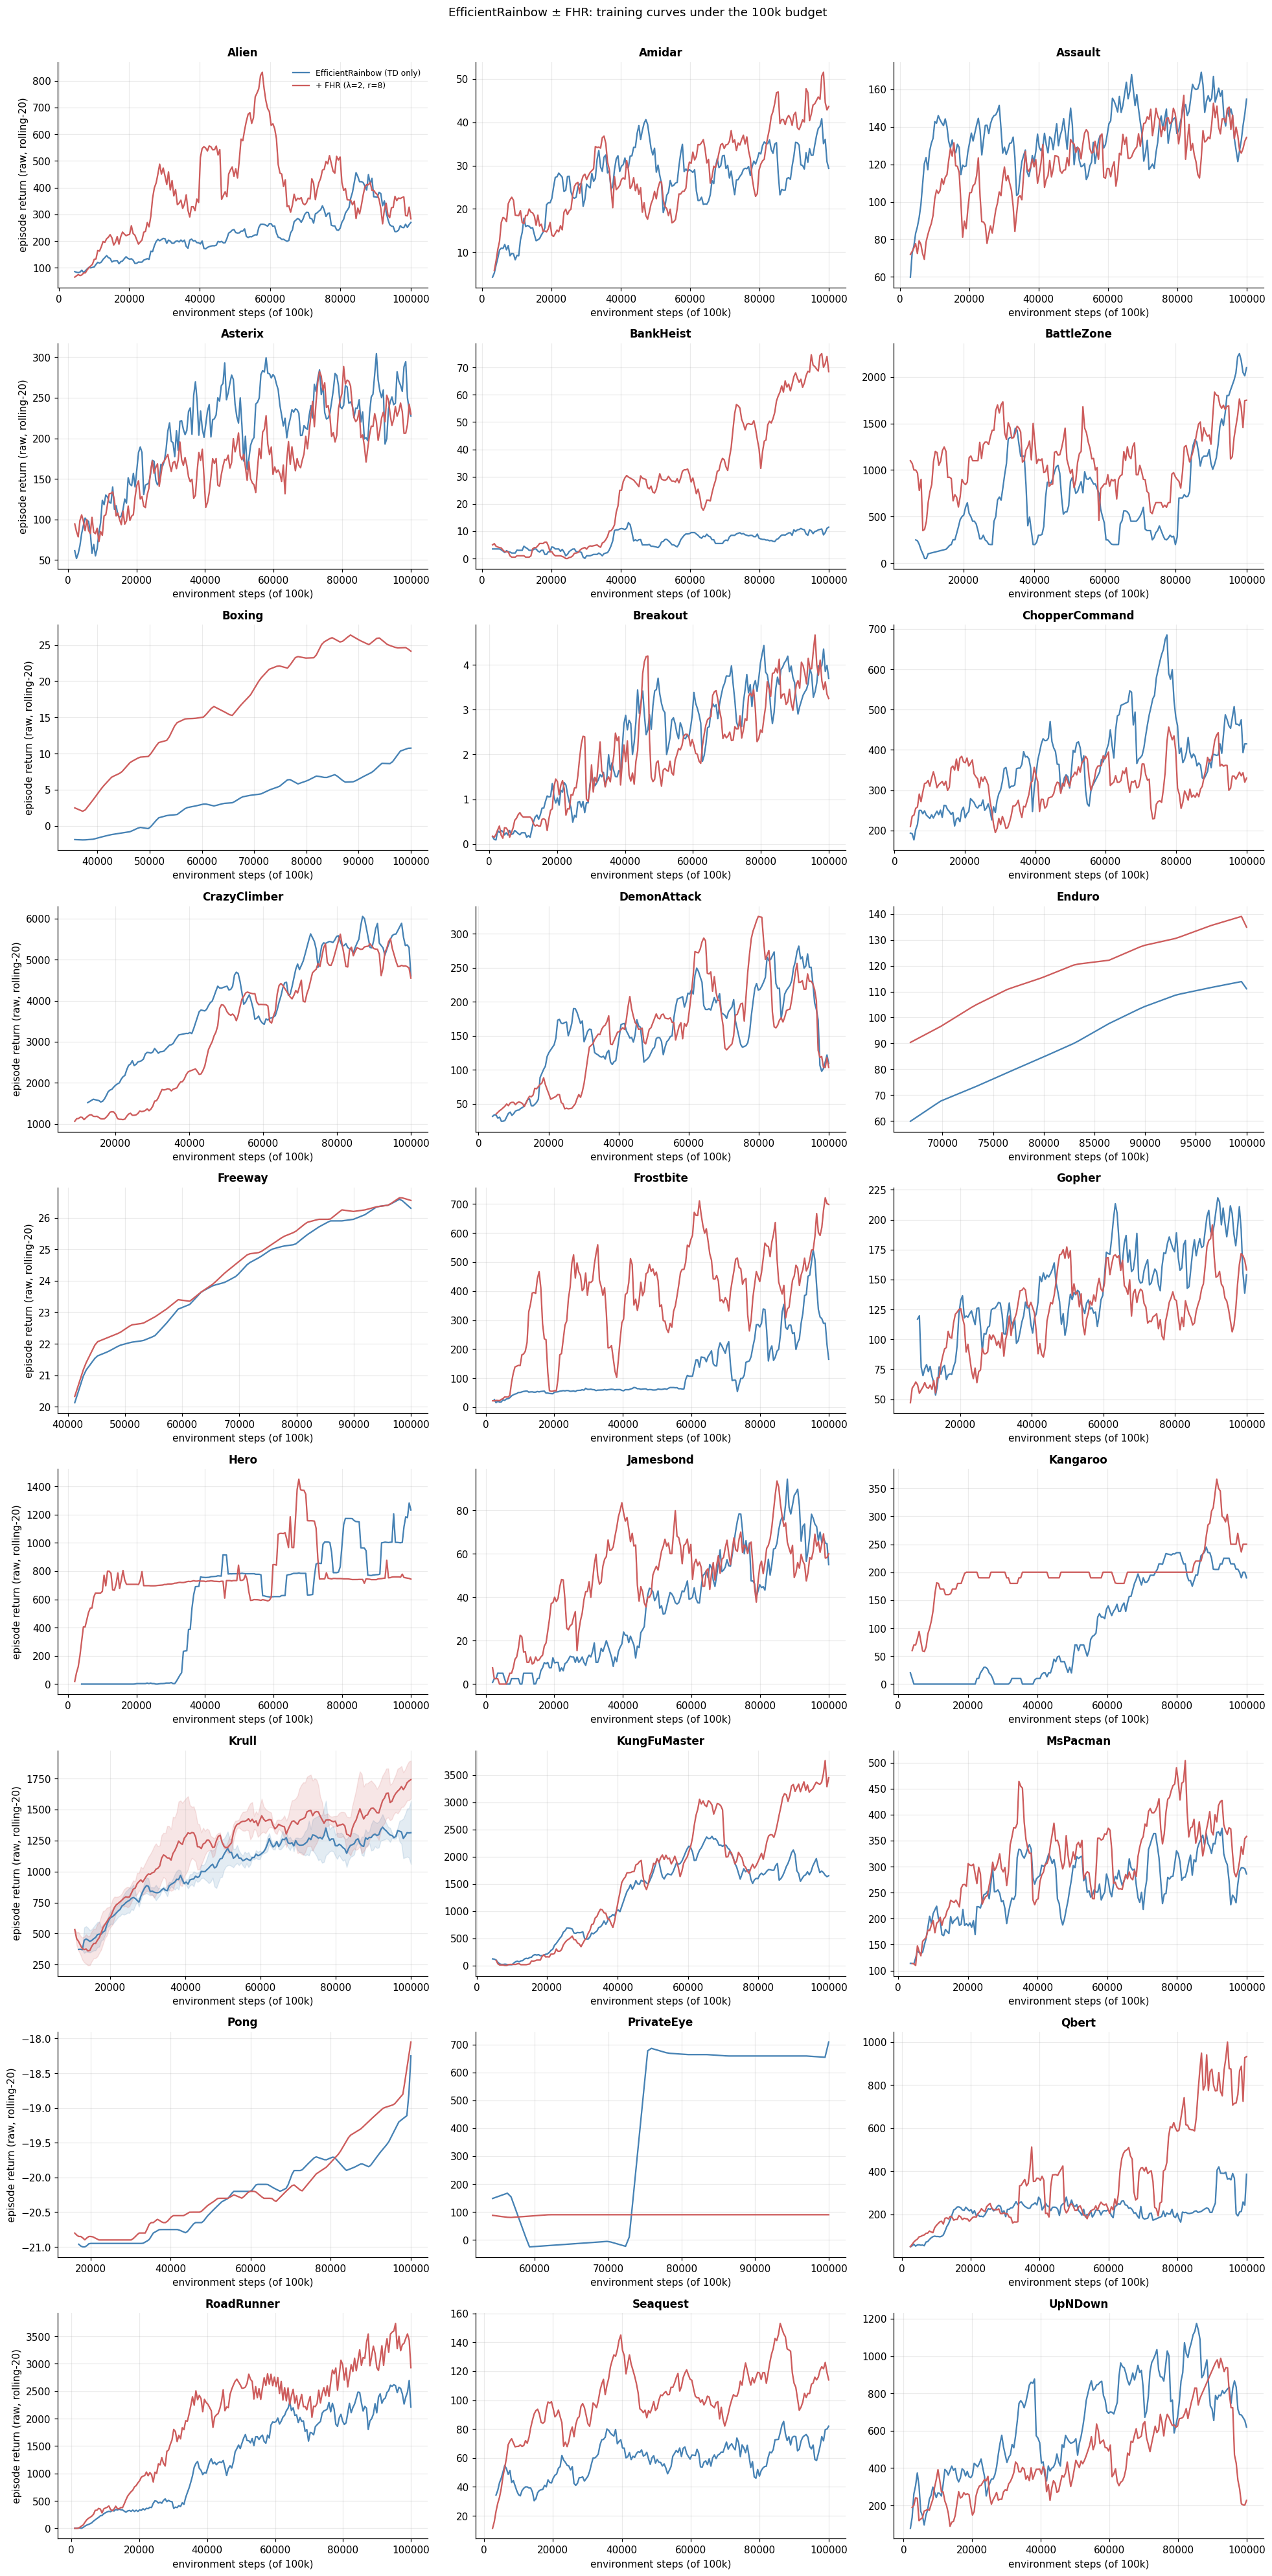

In [6]:
def rolling(x, w):
    x = np.asarray(x, float)
    return x if len(x) < w else np.convolve(x, np.ones(w) / w, mode="valid")

def curve_on_grid(runs, w=20, n=200):
    grid = np.linspace(0, ATARI100K_ENV_STEPS, n)
    stack = np.full((len(runs), n), np.nan)
    for i, r in enumerate(runs):
        steps = np.cumsum(r["steps"]) if r["steps"] is not None else None
        if steps is None or len(r["rewards"]) < w:
            continue
        y = rolling(r["rewards"], w)
        xs = steps[len(steps) - len(y):]
        inside = (grid >= xs[0]) & (grid <= xs[-1])
        stack[i, inside] = np.interp(grid[inside], xs, y)
    return grid, stack

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(6 * NCOLS, 4.0 * NROWS),
                         squeeze=False)
for ax in axes.flat[len(GAMES):]:
    ax.set_visible(False)
for ax, g in zip(axes.flat, GAMES):
    for arm in ARMS:
        if arm not in RESULTS[g]:
            continue
        grid, stack = curve_on_grid(RESULTS[g][arm]["runs"])
        m = np.nanmean(stack, axis=0)
        ax.plot(grid, m, color=OUR_COLOR[arm], label=OUR_LABEL[arm])
        if stack.shape[0] > 1:
            ax.fill_between(grid, np.nanmin(stack, axis=0),
                            np.nanmax(stack, axis=0),
                            color=OUR_COLOR[arm], alpha=0.15)
    ax.set_title(GAME_KEYS[g])
    ax.set_xlabel("environment steps (of 100k)")
for row in axes:
    row[0].set_ylabel("episode return (raw, rolling-20)")
axes.flat[0].legend(fontsize=8)
fig.suptitle("EfficientRainbow ± FHR: training curves under the 100k budget",
             y=1.0 + 0.025 / NROWS)
fig.tight_layout()
save_and_show(fig, "atari100k_effrainbow_learning_curves")

## 5 · Notes for the write-up

- Cite: protocol — Kaiser et al. 2020 (SimPLe); recipe — Kostrikov et al. 2021
  (DrQ, Table 4 "Efficient DQN") with the IQN-8 head; published columns — Ye et
  al. 2021 Table 1 (EfficientZero); random/human — Wang et al. 2016 (30 no-op).
- The honest claim shape: *"under the EfficientRainbow recipe at replay ratio 2,
  adding λ·Huber(order-8 recurrence residual) to the TD loss changes the 100k
  suite aggregate from X to Y (per-game win/loss W–L)"*. The published methods
  contextualise the axis; they are not matched-recipe ablations.
- exp3's r = 8 matching the HalfCheetah FHR-SAC winner (λ0.1·r8) is worth one
  sentence in the thesis: the longer recurrence window is the cross-domain
  choice, r = 2 the classic-control one.
- Per-run mechanism diagnostics (Hankel rank evolution, penalty traces, learned
  coefficients) are browsable in the result viewer (`python
  result_viewer_app/rank_viewer.py`), manifest family `effrainbow100k_runs`,
  baseline-vs-exp3 compare built in. Krull's deeper arm grid (r = 22 probes,
  gameplay clips, BBF cross-recipe synthesis) stays in
  `dqn_krull/exp_effrainbow_fhr_krull_results.ipynb`.

**Executed 2026-08-28, all 27 games (26-suite + Enduro), corrected protocol:**

- **Full-26-game aggregate HNS**: baseline **0.460 mean / 0.211 median** → +FHR
  **0.544 / 0.259** — an 18% relative lift on mean HNS from the penalty alone.
  That places EfficientRainbow+FHR above SimPLe, OTRainbow, CURL, DrQ and
  MuZero's mean on this table, below SPR (0.703/0.415) and EfficientZero
  (1.943/1.090).
- **Per-game: 15 wins / 11 losses / 1 tie** (raw score, all 27 games);
  ΔHNS mean +0.083, median ≈ 0, IQR [−0.061, +0.047]. The mean lift is carried
  by large wins — Boxing +1.47, Krull +0.77, BankHeist +0.62, Frostbite +0.35 —
  while the typical game is a wash and the worst loss is moderate
  (DemonAttack −0.33). The honest sentence: *FHR substantially helps a subset
  of games and is near-neutral elsewhere; it does not degrade the typical
  game.* One seed per game (Krull 2) — the per-game signs are noisy,
  the aggregate and the win-tally are the quotable numbers.